Downloaded LSTM_Multivariate_pollution.csv.
Starting training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0401 - val_loss: 0.0313
Epoch 2/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0192 - val_loss: 0.0144
Epoch 3/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0166 - val_loss: 0.0117
Epoch 4/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0157 - val_loss: 0.0112
Epoch 5/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0153 - val_loss: 0.0113
Epoch 6/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0149 - val_loss: 0.0115
Epoch 7/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0148 - val_loss: 0.0115
Epoch 8/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0147 - val_loss: 0.0113
Epoch 9/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0147 - val_loss: 0.0112
Epoch 10/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0144 - val_loss: 0.0115
Epoch 11/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0145 - val_loss: 0.0117
Epoch 12/20
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.

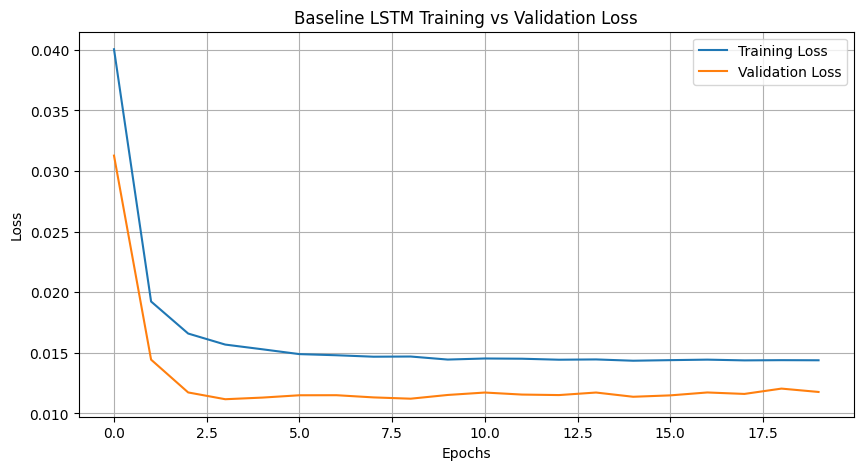

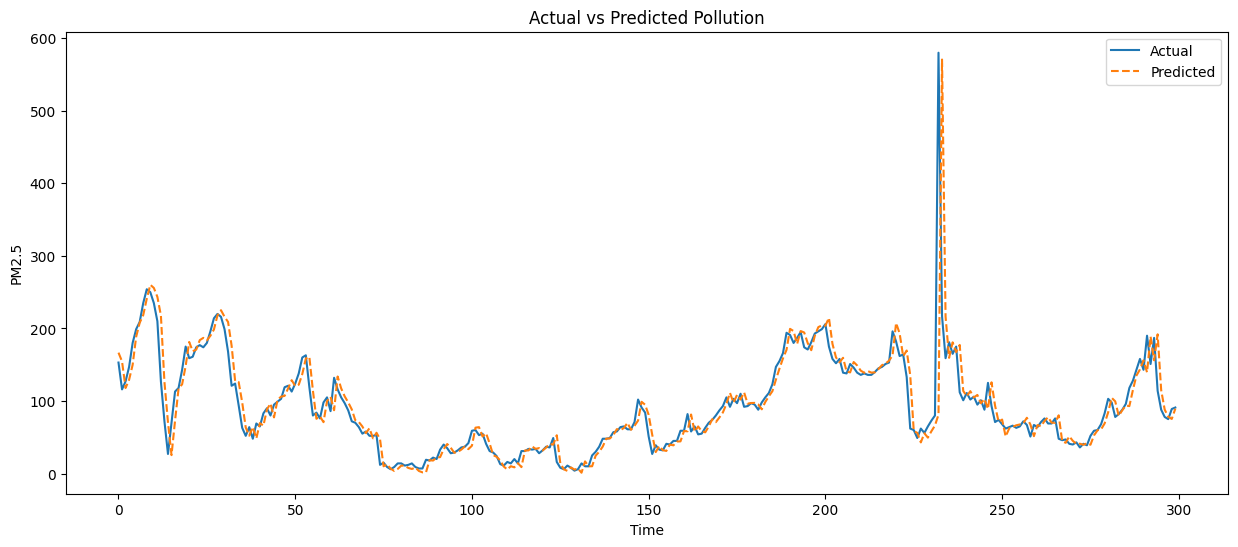

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os
import requests

# 1. LOAD DATASET
file_name = 'LSTM_Multivariate_pollution.csv'
# Ensure the file is always downloaded to prevent using old/corrupt versions
print(f"Downloading {file_name}...")
# Updated URL to a working source for pollution.csv
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
r = requests.get(url, allow_redirects=True)
with open(file_name, 'wb') as f:
    f.write(r.content)
print(f"Downloaded {file_name}.")

# Load CSV and manually parse date columns
df = pd.read_csv(file_name)

# Manually combine date columns to create a datetime index
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('date')

# Drop the original date/time columns and the 'No' column
df.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)

# Rename 'cbwd' to 'wnd_dir' to match the original code's expectation
df.rename(columns={'cbwd': 'wnd_dir'}, inplace=True)

# Reorder columns to ensure 'pm2.5' (the target variable) is the first feature
# This ensures it becomes 'var1' in the supervised learning step
cols = df.columns.tolist()
cols.remove('pm2.5')
df = df[['pm2.5'] + cols]

# 2. DATA PREPROCESSING

# Encode categorical wind direction
encoder = LabelEncoder()
df['wnd_dir'] = encoder.fit_transform(df['wnd_dir'])

# Convert series to supervised learning format
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df_temp = pd.DataFrame(data)
    cols, names = list(), list()

    # Input sequence (t-n ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df_temp.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]

    # Forecast sequence (t)
    for i in range(0, n_out):
        cols.append(df_temp.shift(-i))
        if i == 0:
            names += [f'var{j+1}(t)' for j in range(n_vars)]
        else:
            names += [f'var{j+1}(t+{i})' for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names

    if dropnan:
        agg.dropna(inplace=True)

    return agg

# Scaling
values = df.values.astype('float32')
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# Convert to supervised
reframed = series_to_supervised(scaled, 1, 1)

# Drop unwanted columns
# Based on the typical `pollution.csv` structure and original code's intent (dropping all except var1(t)),
# the last column 'var1(t)' (which is 'pm2.5') should be kept.
# The original code's `reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)`
# is designed to keep 'var1(t)' as the target, assuming 'var1' is 'pm2.5' and there are 8 input features.
# So, the columns var2(t) to var8(t) should be dropped. With 8 features, these are indices 9 to 15 (0-indexed).
reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)

# 3. TRAIN-TEST SPLIT
values = reframed.values
n_train_hours = 365 * 24 * 4

train = values[:n_train_hours, :]
test = values[n_train_hours:, :]

train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]

# Reshape for LSTM
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))

# 4. MODEL
model = Sequential()
model.add(LSTM(50, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss='mae', optimizer='adam')

# 5. TRAINING
print("Starting training...")
history = model.fit(
    train_X, train_y,
    epochs=20,
    batch_size=72,
    validation_data=(test_X, test_y),
    verbose=1,
    shuffle=False
)

# 6. EVALUATION
yhat = model.predict(test_X)

test_X_reshaped = test_X.reshape((test_X.shape[0], test_X.shape[2]))

# Inverse scaling
inv_yhat = np.concatenate((yhat, test_X_reshaped[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)[:, 0]

test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, test_X_reshaped[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)[:, 0]

# Metrics
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))
r2 = r2_score(inv_y, inv_yhat)

print("\n--- PERFORMANCE METRICS ---")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}%)")

# 7. VISUALS

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline LSTM Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Prediction graph
plt.figure(figsize=(15, 6))
plt.plot(inv_y[:300], label='Actual')
plt.plot(inv_yhat[:300], label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Pollution')
plt.xlabel('Time')
plt.ylabel('PM2.5')
plt.legend()
plt.show()

Epoch 1/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0329 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 2/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0219 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 3/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0181 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 4/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0162 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 5/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0154 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 6/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0154 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 7/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0151 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 8/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0150 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 9/50
548/548 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0152 - val_loss: 0.0107 - learning_rate: 0.0010

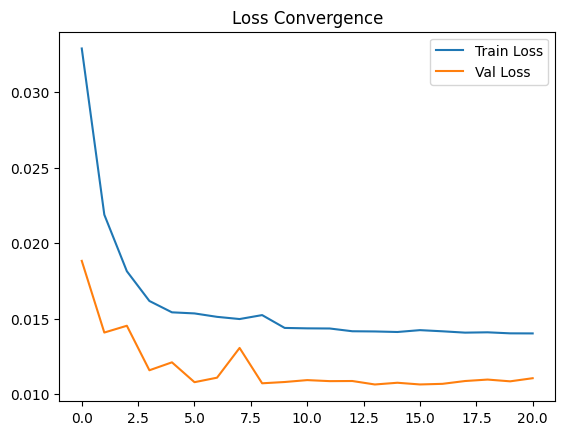

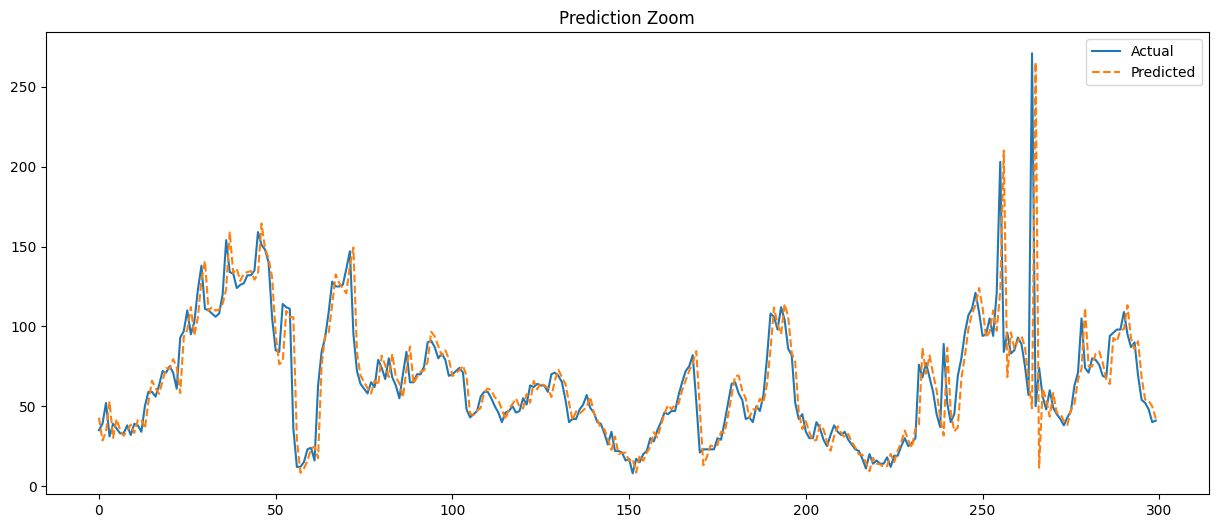

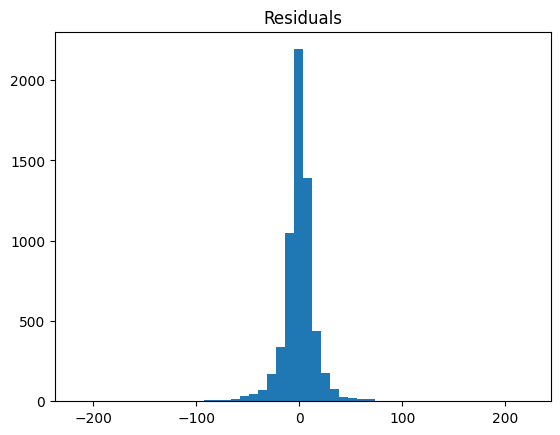

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Load data
df = pd.read_csv('LSTM_Multivariate_pollution.csv') # Load without index_col initially

# Manually combine date columns to create a datetime index
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('date')

# Drop the original date/time columns and the 'No' column
df.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)

# Rename 'cbwd' to 'wnd_dir' to match the original code's expectation
df.rename(columns={'cbwd': 'wnd_dir'}, inplace=True)

# Reorder columns to ensure 'pm2.5' (the target variable) is the first feature
# This ensures it becomes 'var1' in the supervised learning step
cols = df.columns.tolist()
cols.remove('pm2.5')
df = df[['pm2.5'] + cols]

# Encode categorical
encoder = LabelEncoder()
df['wnd_dir'] = encoder.fit_transform(df['wnd_dir'])

# Convert to supervised (this definition was incorrect, using the more robust one below)
# This is the improved series_to_supervised function, renamed for clarity
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df_temp = pd.DataFrame(data)
    cols, names = list(), list()

    # Input sequence (t-n ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df_temp.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]

    # Forecast sequence (t, t+1, ... t+n_out-1)
    for i in range(0, n_out):
        cols.append(df_temp.shift(-i))
        if i == 0:
            names += [f'var{j+1}(t)' for j in range(n_vars)]
        else:
            names += [f'var{j+1}(t+{i})' for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names

    if dropnan:
        agg.dropna(inplace=True)

    return agg

# Scaling
values = df.values.astype('float32')
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# Lookback = 3
n_hours = 3
n_features = 8 # Ensure this matches the number of features in your df

# Create reframed with all 't' columns using the improved function
reframed_full = series_to_supervised(scaled, n_hours, 1)

# Now, separate inputs (X) and outputs (y), keeping all 't' outputs for inverse scaling.
# The last `n_features` columns are `var1(t), var2(t), ..., varN(t)`
# We want `var1(t)` as the actual target `y`, and `var2(t)` to `varN(t)` to assist inverse scaling.

# Split into input and output columns for training
X_data = reframed_full.iloc[:, :-n_features].values  # Input features (t-n_hours to t-1 for all features)
y_target_pm25 = reframed_full.iloc[:, -n_features].values # This is var1(t) (pm2.5 at t)
y_all_features_at_t = reframed_full.iloc[:, -n_features:].values # All features at time t, for inverse scaling

# Define train/test split size
n_train = 365 * 24 * 4

# Split X_data and y_target_pm25 into training and testing sets
train_X_full = X_data[:n_train]
train_y = y_target_pm25[:n_train]
test_X_full = X_data[n_train:]
test_y = y_target_pm25[n_train:]

# Also split y_all_features_at_t for inverse scaling
test_y_all_features_t = y_all_features_at_t[n_train:]

# Reshape for LSTM
train_X = train_X_full.reshape((train_X_full.shape[0], n_hours, n_features))
test_X = test_X_full.reshape((test_X_full.shape[0], n_hours, n_features))

# Model
model = Sequential()
model.add(Input(shape=(n_hours, n_features)))
model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.001)
model.compile(loss='mae', optimizer=optimizer)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train
history = model.fit(
    train_X, train_y,
    epochs=50,
    batch_size=64,
    validation_data=(test_X, test_y),
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False
)

# Prediction
yhat = model.predict(test_X)

# Inverse scaling: now we have `test_y_all_features_t` for reconstruction
# `yhat` is a column vector of predicted pm2.5 values.
# We need to replace the first column of `test_y_all_features_t` (which is actual pm2.5) with `yhat`.

inv_yhat_concat = np.concatenate((yhat, test_y_all_features_t[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat_concat)[:, 0]

# Inverse transform the actual values for comparison
inv_y_concat = test_y_all_features_t
inv_y = scaler.inverse_transform(inv_y_concat)[:, 0]

# Metrics
rmse = np.sqrt(mean_squared_error(inv_y, inv_yhat))
r2 = r2_score(inv_y, inv_yhat)

print("\n--- OPTIMIZED MODEL RESULTS ---")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f} ({r2*100:.2f}%)")

# Visuals
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Convergence')
plt.show()

plt.figure(figsize=(15,6))
plt.plot(inv_y[500:800], label='Actual')
plt.plot(inv_yhat[500:800], label='Predicted', linestyle='--')
plt.legend()
plt.title('Prediction Zoom')
plt.show()

residuals = inv_y - inv_yhat
plt.hist(residuals, bins=50)
plt.title('Residuals')
plt.show()